Load Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, date
import datetime
import seaborn as sns

Load data

In [3]:
data = pd.read_csv("all_data.csv")
data.drop(data.columns[-1], axis = 1, inplace= True)

/var/folders/bg/5dmr_ymn0g7d0fqz7043vr8c0000gp/T/ipykernel_1193/1039843311.py:1: DtypeWarning: Columns (0,4,12) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("all_data.csv")


In [4]:
loc1 = data[data["Name"] == "Location 20"]
loc1.head()

,Name,Longitude,Latitude,Elevation (ft),Date,ppt (inches),tmin (degrees F),tmean (degrees F),tmax (degrees F),tdmean (degrees F),vpdmin (hPa),vpdmax (hPa)
6954,Location 20,-121.7489,36.7085,20.0,1/1/2017,0.00,39.9,47.6,55.2,39.3,0.72,7.05
6955,Location 20,-121.7489,36.7085,20.0,1/2/2017,0.05,41.5,47.0,52.5,39.7,0.69,5.30
6956,Location 20,-121.7489,36.7085,20.0,1/3/2017,0.12,42.4,46.4,50.4,44.5,0.37,2.20
6957,Location 20,-121.7489,36.7085,20.0,1/4/2017,1.22,48.0,52.5,57.0,49.1,0.47,4.61
6958,Location 20,-121.7489,36.7085,20.0,1/5/2017,0.25,50.3,54.9,59.5,54.5,0.13,1.42


In [5]:
def retrieve_date(str):
    month, date, year = [int(item) for item in str.split("/")]
    return datetime.datetime(year, month, date).timestamp()
dates_float =list(map(retrieve_date, loc1["Date"]))

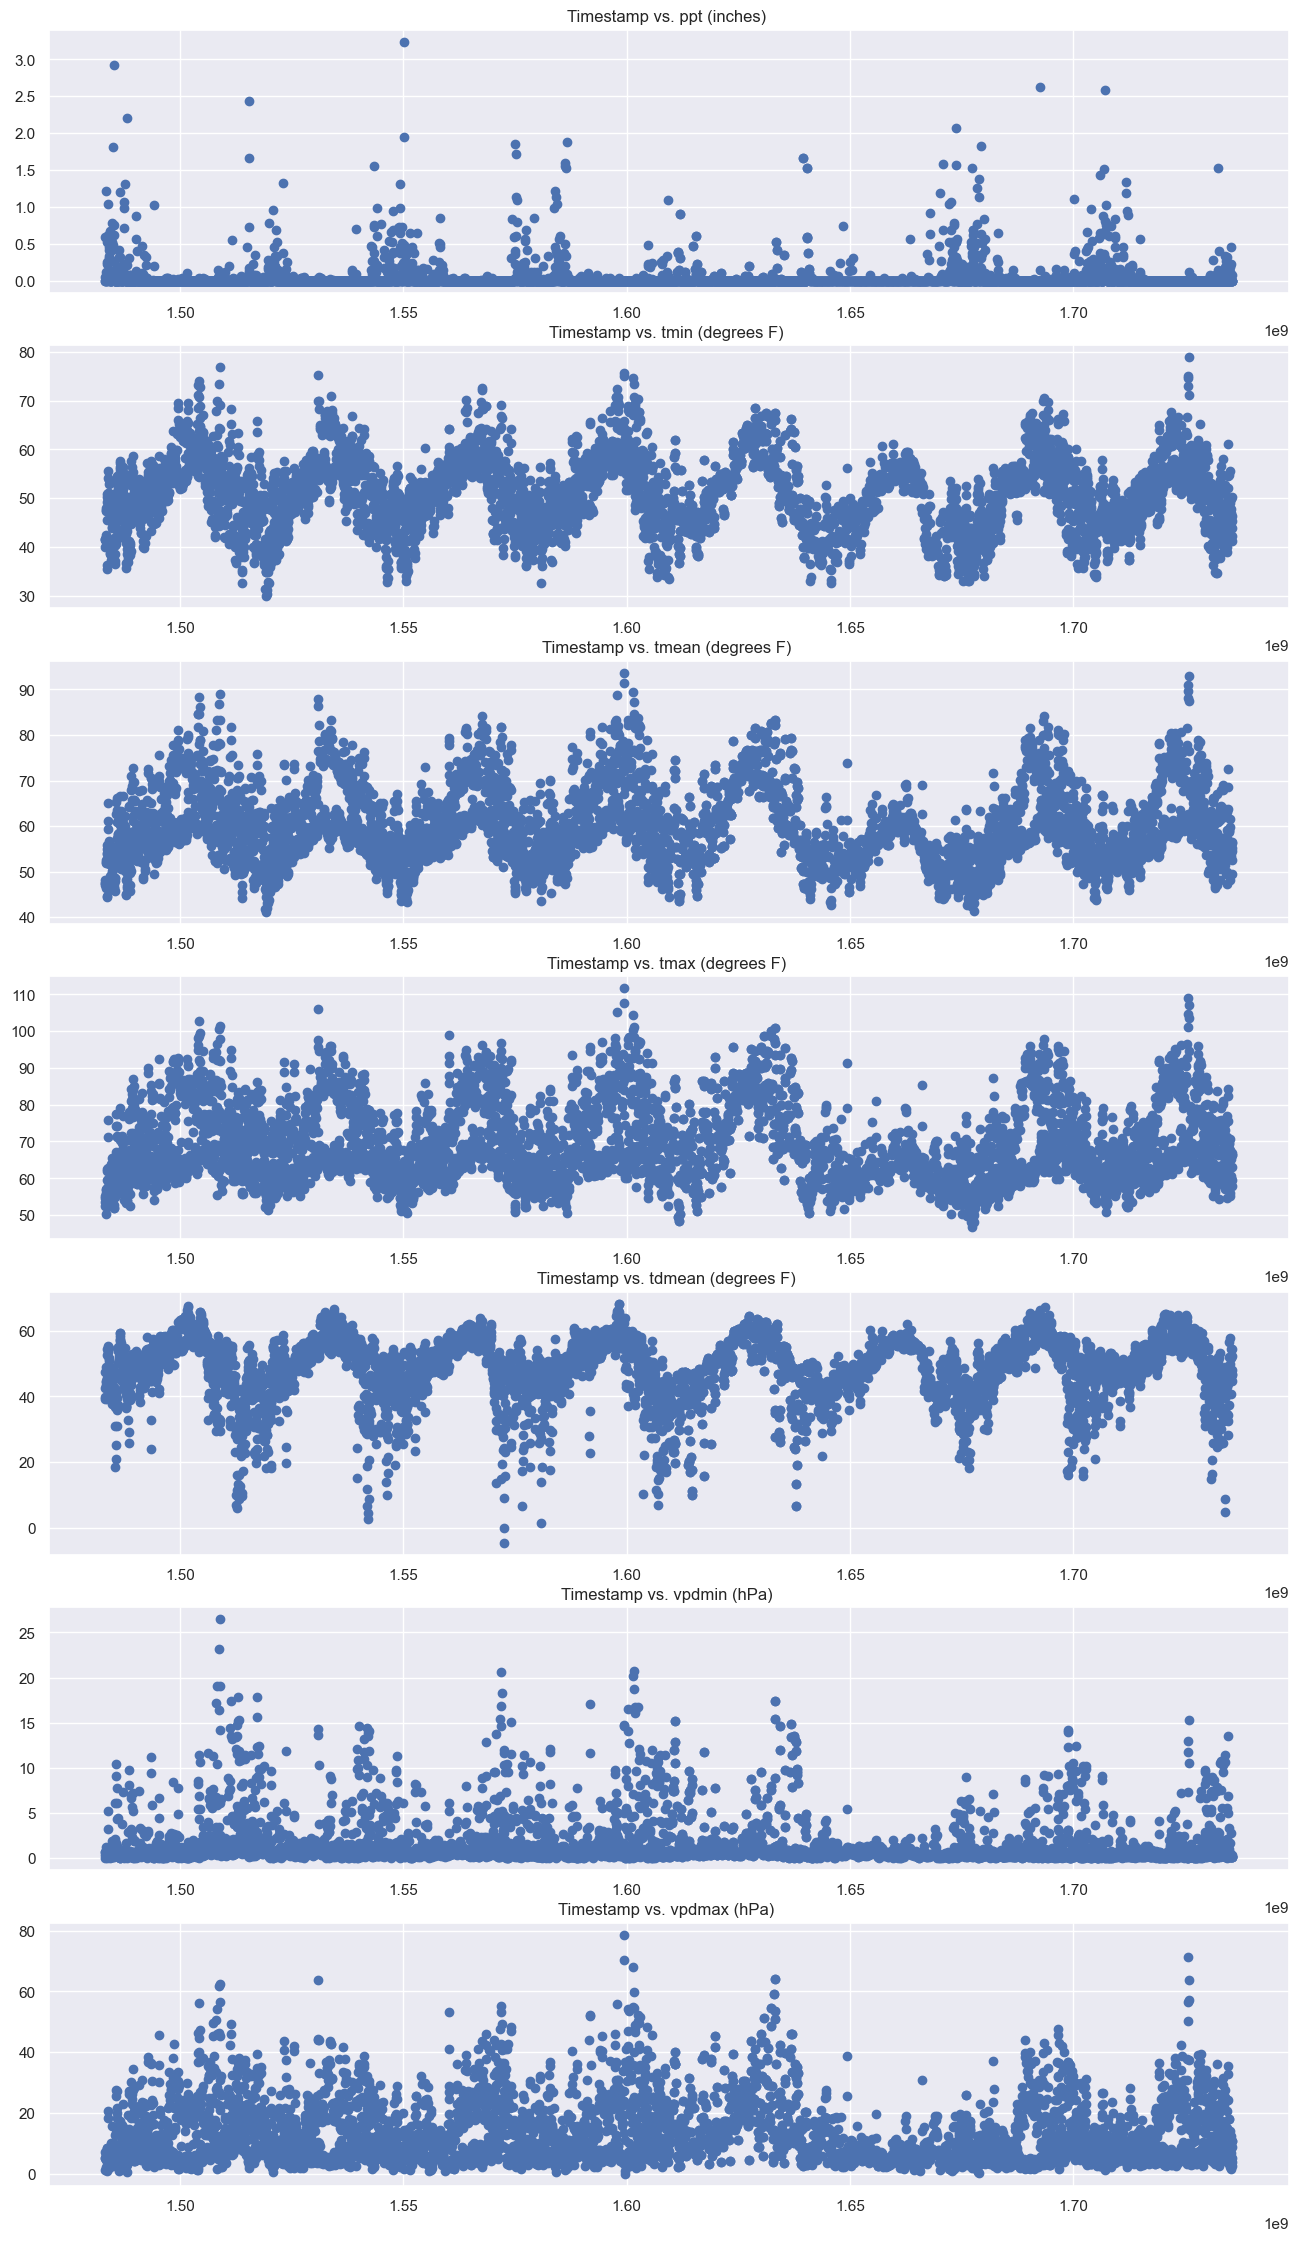

In [6]:
cols = data.columns[5:]
sns.set_theme()
fig, axs = plt.subplots(7, 1, figsize = (16, 28))
for i in range(7):
    axs[i].scatter(x = dates_float, y= loc1[cols[i]])
    axs[i].set_title(f"Timestamp vs. {cols[i]} ")
plt.show()


- Points <= 0.1 - dry period
- Points > 0.1 - wet period

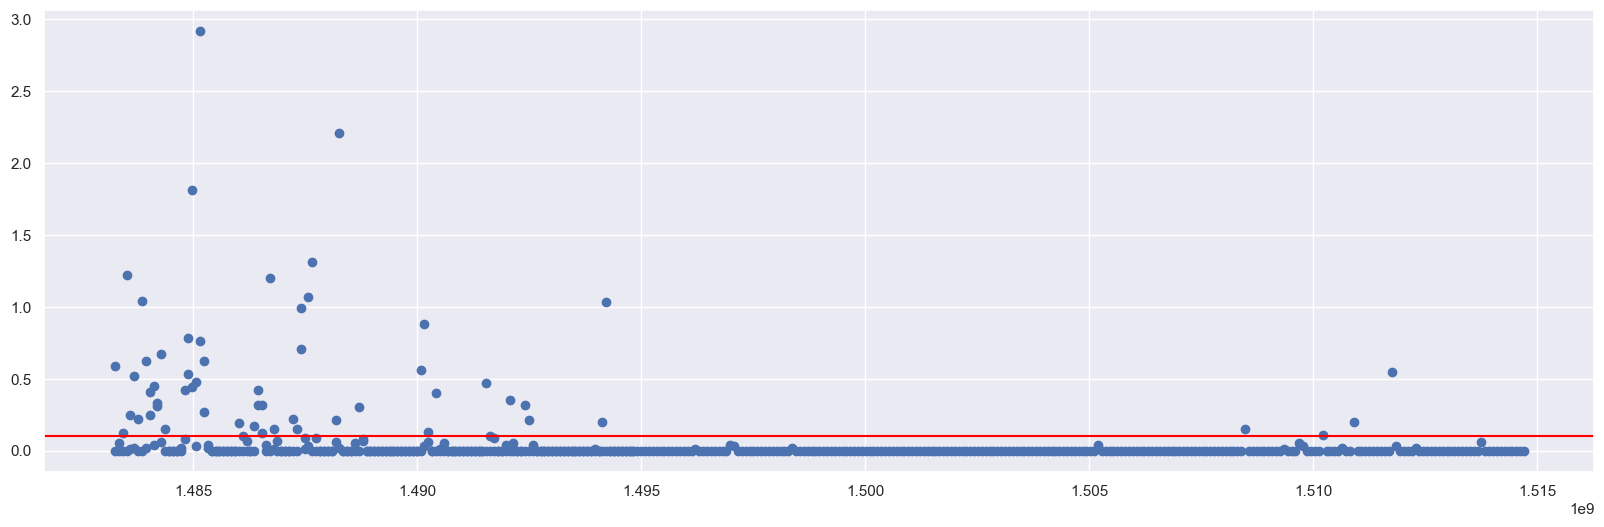

In [26]:
points = 500
plt.figure(figsize=(20,6))
plt.axhline(0.1, color = "red")
#plt.axhline(0.2, color = "orange")
plt.scatter(x = dates_float[0:points], y= loc1["ppt (inches)"][0:points])
plt.show()

In [11]:
data.columns

Index(['Name', 'Longitude', 'Latitude', 'Elevation (ft)', 'Date',
       'ppt (inches)', 'tmin (degrees F)', 'tmean (degrees F)',
       'tmax (degrees F)', 'tdmean (degrees F)', 'vpdmin (hPa)',
       'vpdmax (hPa)'],
      dtype='object')